In [1]:
import os
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# **DATA CLEANING AND PRE-PROCESSING**

In [2]:
!pip install -q kagglehub

In [3]:
import kagglehub

path = kagglehub.dataset_download("karkavelrajaj/amazon-sales-dataset")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'amazon-sales-dataset' dataset.
Dataset downloaded to: /kaggle/input/amazon-sales-dataset


In [4]:
import os

print(os.listdir(path))

['amazon.csv']


In [5]:
import pandas as pd

file_path = os.path.join(path, "amazon.csv")

df = pd.read_csv(file_path)

df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,₹399,"₹1,099",64%,4.2,"24,269","High Compatibility : Compatible With iPhone 12, 11, X/XsMax/Xr ,iPhone 8/8 Plus,iPhone 7/7 Plus,...","AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBBSNLYT3ONILA,AHCTC6ULH4XB6YHDY6PCH2R772LQ,AGYHHIERN...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jaspreet singh,Khaja moin,Anand,S.ARUMUGAM","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1KD19VHEDV0OR,R3C02RMYQMK6FC,R39GQRVBUZBWGY,R2K9EDOE...","Satisfied,Charging is really fast,Value for money,Product review,Good quality,Good product,Good ...","Looks durable Charging is fine tooNo complains,Charging is really fast, good product.,Till now s...",https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/51UsScvHQNL._SX300_SY300_QL70_FMwebp...,https://www.amazon.in/Wayona-Braided-WN3LG1-Syncing-Charging/dp/B07JW9H4J1/ref=sr_1_1?qid=167290...
1,B098NS6PVG,"Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Type C Cable for Smartphones, Tablets, L...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be it an android smartphone (Mi, Samsung, Oppo, Vivo...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBXNGXZJT525AQ,AHONIZU3ICIEHQIGQ6R2VFRSBXOQ,AFPHD2CRP...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Placeholder,BharanI,sonia,Niam","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RYGGS0M09S3KY,R17KQRUTAN5DKS,R3AAQGS6HP2QUK,R1HDNOG6...","A Good Braided Cable for Your Type C Device,Good quality product from ambrane,Super cable,As,Goo...",I ordered this cable to connect my phone to Android Auto of car. The cable is really strong and ...,https://m.media-amazon.com/images/W/WEBP_402378-T2/images/I/31zOsqQOAOL._SY445_SX342_QL70_FMwebp...,https://www.amazon.in/Ambrane-Unbreakable-Charging-Braided-Cable/dp/B098NS6PVG/ref=sr_1_2?qid=16...
2,B096MSW6CT,"Sounce Fast Phone Charging Cable & Data Sync USB Cable Compatible for iPhone 13, 12,11, X, 8, 7,...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safety proctections and four-core copper wires promote ...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQLWQOWZ4N3OA,AHTPQRIMGUD4BYR5YIHBH3CCGEFQ,AEUVWXYP5...","Kunal,Himanshu,viswanath,sai niharka,saqib malik,Aashiq,Ramu Challa,Sanjay gupta","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R25X4TBMPY91LX,R27OK7G99VK0TR,R207CYDCHJJTCJ,R3PCU8X...","Good speed for earlier versions,Good Product,Working good,Good for the price,Good,Worth for mone...","Not quite durable and sturdy,https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/71rIggr...",https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/31IvNJZnmdL._SY445_SX342_QL70_FMwebp...,https://www.amazon.in/Sounce-iPhone-Charging-Compatible-Devices/dp/B096MSW6CT/ref=sr_1_3?qid=167...
3,B08HDJ86NZ,"boAt Deuce USB 300 2 in 1 Type-C & Micro USB Stress Resistant, Tangle-Free, Sturdy Cable with 3A...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,₹329,₹699,53%,4.2,"94,363","The boAt Deuce USB 300 2 in 1 cable is compatible with smartphones, tablets, PC peripherals, Blu...","AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5SGCUQBP7YSCA,AH725ST5NW2Y4JZPKUNTIJCUK2BA,AHV3TXIFC...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh chouhan,Ravi Siddan,Himanshu Goel,Udaykumar","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1CLH2ULIVG5U3,R2DMKIBGFKBD6R,RC89B5IAJUTR5,R3B3DDON...","Good product,Good one,Nice,Really nice product,Very first time change,Good,Fine product but coul...","Good product,long wire,Charges 

In [6]:
print("Shape:", df.shape)

df.info()

display(df.isnull().sum())

display(df.head())

display(df.describe(include="all"))

Shape: (1465, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,₹399,"₹1,099",64%,4.2,"24,269","High Compatibility : Compatible With iPhone 12, 11, X/XsMax/Xr ,iPhone 8/8 Plus,iPhone 7/7 Plus,...","AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBBSNLYT3ONILA,AHCTC6ULH4XB6YHDY6PCH2R772LQ,AGYHHIERN...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jaspreet singh,Khaja moin,Anand,S.ARUMUGAM","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1KD19VHEDV0OR,R3C02RMYQMK6FC,R39GQRVBUZBWGY,R2K9EDOE...","Satisfied,Charging is really fast,Value for money,Product review,Good quality,Good product,Good ...","Looks durable Charging is fine tooNo complains,Charging is really fast, good product.,Till now s...",https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/51UsScvHQNL._SX300_SY300_QL70_FMwebp...,https://www.amazon.in/Wayona-Braided-WN3LG1-Syncing-Charging/dp/B07JW9H4J1/ref=sr_1_1?qid=167290...
1,B098NS6PVG,"Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Type C Cable for Smartphones, Tablets, L...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be it an android smartphone (Mi, Samsung, Oppo, Vivo...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBXNGXZJT525AQ,AHONIZU3ICIEHQIGQ6R2VFRSBXOQ,AFPHD2CRP...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Placeholder,BharanI,sonia,Niam","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RYGGS0M09S3KY,R17KQRUTAN5DKS,R3AAQGS6HP2QUK,R1HDNOG6...","A Good Braided Cable for Your Type C Device,Good quality product from ambrane,Super cable,As,Goo...",I ordered this cable to connect my phone to Android Auto of car. The cable is really strong and ...,https://m.media-amazon.com/images/W/WEBP_402378-T2/images/I/31zOsqQOAOL._SY445_SX342_QL70_FMwebp...,https://www.amazon.in/Ambrane-Unbreakable-Charging-Braided-Cable/dp/B098NS6PVG/ref=sr_1_2?qid=16...
2,B096MSW6CT,"Sounce Fast Phone Charging Cable & Data Sync USB Cable Compatible for iPhone 13, 12,11, X, 8, 7,...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safety proctections and four-core copper wires promote ...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQLWQOWZ4N3OA,AHTPQRIMGUD4BYR5YIHBH3CCGEFQ,AEUVWXYP5...","Kunal,Himanshu,viswanath,sai niharka,saqib malik,Aashiq,Ramu Challa,Sanjay gupta","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R25X4TBMPY91LX,R27OK7G99VK0TR,R207CYDCHJJTCJ,R3PCU8X...","Good speed for earlier versions,Good Product,Working good,Good for the price,Good,Worth for mone...","Not quite durable and sturdy,https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/71rIggr...",https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/31IvNJZnmdL._SY445_SX342_QL70_FMwebp...,https://www.amazon.in/Sounce-iPhone-Charging-Compatible-Devices/dp/B096MSW6CT/ref=sr_1_3?qid=167...
3,B08HDJ86NZ,"boAt Deuce USB 300 2 in 1 Type-C & Micro USB Stress Resistant, Tangle-Free, Sturdy Cable with 3A...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,₹329,₹699,53%,4.2,"94,363","The boAt Deuce USB 300 2 in 1 cable is compatible with smartphones, tablets, PC peripherals, Blu...","AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5SGCUQBP7YSCA,AH725ST5NW2Y4JZPKUNTIJCUK2BA,AHV3TXIFC...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh chouhan,Ravi Siddan,Himanshu Goel,Udaykumar","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1CLH2ULIVG5U3,R2DMKIBGFKBD6R,RC89B5IAJUTR5,R3B3DDON...","Good product,Good one,Nice,Really nice product,Very first time change,Good,Fine product but coul...","Good product,long wire,Charges 

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B083342NKJ,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Watch with Bluetooth Calling, AI Voice Assistance, 10...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes with charging & Data sync function|[HIGH QUALITY MATE...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPYWP2OUPEYNPQ,AEBWA5I4QFCA3P3OBEPMELBGN4GQ,AHMGAC6QM...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger Planet,Justice ⚖️,indrajyoti d.,Aditya Kumar,E.C.GE...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,RDVX50PD4CTFE,R3H6WKG0TA5CGU,R3Q3L1KP5QWPV3,RU0LU2P...","Worked on iPhone 7 and didn’t work on XR,Good one,Dull Physical Looks,Just Buy it,Go for it,Abou...","I am not big on camera usage, personally. I was even mentally prepared for a bad camera, based o...",https://m.media-amazon.com/images/I/413sCRKobNL._SX300_SY300_QL70_ML2_.jpg,https://www.amazon.in/Borosil-Jumbo-1000-Watt-Grill-Sandwich/dp/B01486F4G6/ref=sr_1_506?qid=1672...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [7]:
print("Shape:", df.shape)
df.info()

Shape: (1465, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   

In [8]:
import pandas as pd
import numpy as np


df_clean = df.copy()


df_clean['discounted_price'] = (
    df_clean['discounted_price']
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

df_clean['actual_price'] = (
    df_clean['actual_price']
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)


df_clean['discount_percentage'] = (
    df_clean['discount_percentage']
    .str.replace('%', '', regex=False)
    .astype(float)
)


df_clean['rating'] = pd.to_numeric(
    df_clean['rating'],
    errors='coerce'
)


df_clean['rating_count'] = (
    df_clean['rating_count']
    .str.replace(',', '', regex=False)
)

df_clean['rating_count'] = pd.to_numeric(
    df_clean['rating_count'],
    errors='coerce'
)


df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1464 non-null   float64
 7   rating_count         1463 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [9]:
df_clean.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,1
rating_count,2
about_product,0
user_id,0


In [10]:

df_clean['rating'] = df_clean['rating'].fillna(
    df_clean['rating'].median()
)


df_clean['rating_count'] = df_clean['rating_count'].fillna(
    df_clean['rating_count'].median()
)


print(df_clean.isnull().sum())

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [11]:
df_clean[['actual_price',
          'discounted_price',
          'discount_percentage',
          'rating',
          'rating_count']].head()

,actual_price,discounted_price,discount_percentage,rating,rating_count
0,1099.0,399.0,64.0,4.2,24269.0
1,349.0,199.0,43.0,4.0,43994.0
2,1899.0,199.0,90.0,3.9,7928.0
3,699.0,329.0,53.0,4.2,94363.0
4,399.0,154.0,61.0,4.2,16905.0


In [12]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [13]:
numeric_columns = [
    'actual_price',
    'discounted_price',
    'discount_percentage',
    'rating',
    'rating_count'
]

display(df_clean[numeric_columns].describe())

,actual_price,discounted_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000
mean,5444.990635,3125.310874,47.691468,4.096587,18277.634812
std,10874.826864,6944.304394,21.635905,0.291574,42727.398216
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,800.000000,325.000000,32.000000,4.000000,1191.000000
50%,1650.000000,799.000000,50.000000,4.100000,5179.000000
75%,4295.000000,1999.000000,63.000000,4.300000,17325.000000
max,139900.000000,77990.000000,94.000000,5.000000,426973.000000


In [14]:
df_clean['discount_amount'] = (
    df_clean['actual_price'] -
    df_clean['discounted_price']
)

In [15]:
df_clean['price_ratio'] = (
    df_clean['discounted_price'] /
    df_clean['actual_price']
)

In [16]:
df_clean['review_popularity'] = np.log1p(
    df_clean['rating_count']
)

In [17]:
df_clean.head().describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count,discount_amount,price_ratio,review_popularity
count,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.000000
mean,256.000000,889.000000,62.20000,4.100000,37491.800000,633.00000,0.378937,10.191490
std,103.295692,638.748777,17.54138,0.141421,34457.542856,631.66051,0.173533,0.940131
min,154.000000,349.000000,43.00000,3.900000,7928.000000,150.00000,0.104792,8.978282
25%,199.000000,399.000000,53.00000,4.000000,16905.000000,245.00000,0.363057,9.735424
50%,199.000000,699.000000,61.00000,4.200000,24269.000000,370.00000,0.385965,10.096996
75%,329.000000,1099.000000,64.00000,4.200000,43994.000000,700.00000,0.470672,10.691831
max,399.000000,1899.000000,90.00000,4.200000,94363.000000,1700.00000,0.570201,11.454915


In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_clean[
    ['rating_score',
     'review_score',
     'discount_score']
] = scaler.fit_transform(
    df_clean[
        ['rating',
         'review_popularity',
         'discount_percentage']
    ]
)

In [19]:
df_clean['product_value_score'] = (
    0.50 * df_clean['rating_score'] +
    0.30 * df_clean['review_score'] +
    0.20 * df_clean['discount_score']
)

In [20]:
display(
    df_clean[
        [
            'product_name',
            'category',
            'actual_price',
            'discounted_price',
            'discount_percentage',
            'rating',
            'rating_count',
            'product_value_score'
        ]
    ].head(10)
)

,product_name,category,actual_price,discounted_price,discount_percentage,rating,rating_count,product_value_score
0,Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,1099.0,399.00,64.0,4.2,24269.0,0.730339
1,"Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Type C Cable for Smartphones, Tablets, L...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,349.0,199.00,43.0,4.0,43994.0,0.667364
2,"Sounce Fast Phone Charging Cable & Data Sync USB Cable Compatible for iPhone 13, 12,11, X, 8, 7,...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,1899.0,199.00,90.0,3.9,7928.0,0.707375
3,"boAt Deuce USB 300 2 in 1 Type-C & Micro USB Stress Resistant, Tangle-Free, Sturdy Cable with 3A...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,699.0,329.00,53.0,4.2,94363.0,0.741267
4,Portronics Konnect L 1.2M Fast Charging 3A 8 Pin USB Cable with Charge & Sync Function for iPhon...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,399.0,154.00,61.0,4.2,16905.0,0.714815
5,"pTron Solero TB301 3A Type-C Data and Fast Charging Cable, Made in India, 480Mbps Data Sync, Str...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,1000.0,149.00,85.0,3.9,24871.0,0.725640
6,"boAt Micro USB 55 Tangle-free, Sturdy Micro USB Cable with 3A Fast Charging & 480mbps Data Trans...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,499.0,176.63,65.0,4.1,15188.0,0.703951
7,MI Usb Type-C Cable Smartphone (Black),Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,299.0,229.00,23.0,4.3,30411.0,0.665476
8,"TP-Link USB WiFi Adapter for PC(TL-WN725N), N150 Wireless Network Adapter for Desktop - Nano Siz...",Computers&Accessories|NetworkingDevices|NetworkAdapters|WirelessUSBAdapters,999.0,499.00,50.0,4.2,179691.0,0.751168
9,"Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Micro USB Cable for Smartphones, Tablets...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,299.0,199.00,33.0,4.0,43994.0,0.646088


# **EXPLORATORY DATA ANALYSIS**

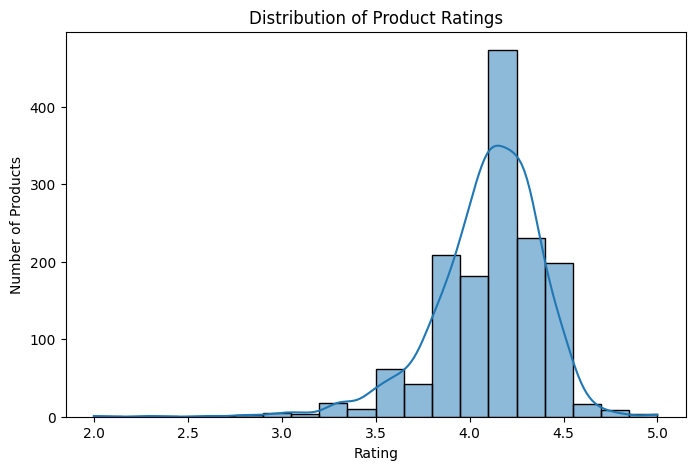

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean['rating'],
    bins=20,
    kde=True
)

plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Products')

plt.show()

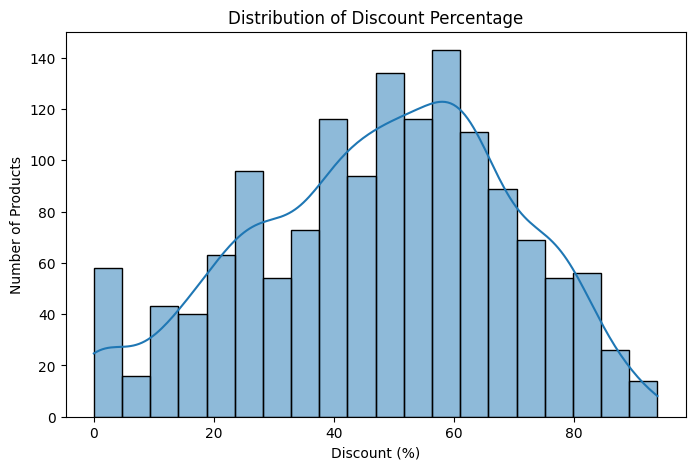

In [22]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean['discount_percentage'],
    bins=20,
    kde=True
)

plt.title('Distribution of Discount Percentage')
plt.xlabel('Discount (%)')
plt.ylabel('Number of Products')

plt.show()

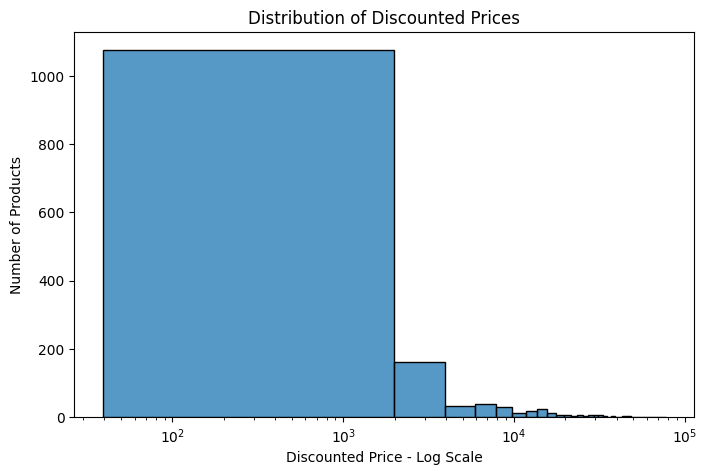

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean['discounted_price'],
    bins=40
)

plt.xscale('log')

plt.title('Distribution of Discounted Prices')
plt.xlabel('Discounted Price - Log Scale')
plt.ylabel('Number of Products')

plt.show()

In [24]:
display(
    df_clean['category'].value_counts().head(10)
)

,count
category,
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,233
Electronics|WearableTechnology|SmartWatches,76
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones,68
"Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions",63
"Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear",52
"Electronics|HomeTheater,TV&Video|Accessories|RemoteControls",49
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|MixerGrinders,27
"Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Mice",24
"Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables",24


In [25]:
df_clean['main_category'] = (
    df_clean['category']
    .astype(str)
    .str.split('|')
    .str[0]
)

In [26]:
display(
    df_clean['main_category'].value_counts().head(15)
)

,count
main_category,
Electronics,526
Computers&Accessories,453
Home&Kitchen,448
OfficeProducts,31
MusicalInstruments,2
HomeImprovement,2
Toys&Games,1
Car&Motorbike,1
Health&PersonalCare,1


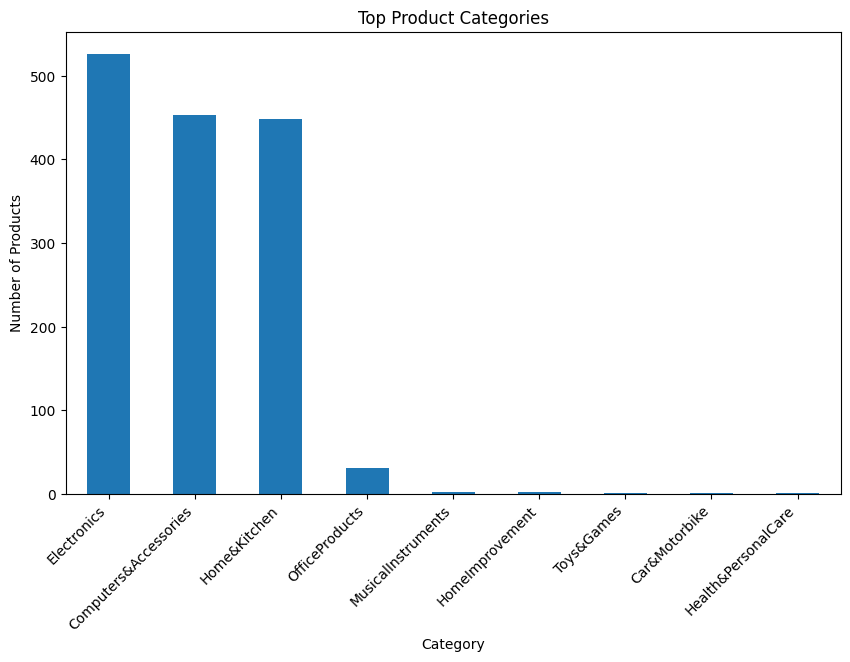

In [27]:
plt.figure(figsize=(10, 6))

df_clean['main_category'].value_counts().head(15).plot(
    kind='bar'
)

plt.title('Top Product Categories')
plt.xlabel('Category')
plt.ylabel('Number of Products')

plt.xticks(rotation=45, ha='right')

plt.show()

In [28]:
category_rating = (
    df_clean
    .groupby('main_category')['rating']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

display(category_rating)

,rating
main_category,
OfficeProducts,4.309677
Toys&Games,4.300000
HomeImprovement,4.250000
Computers&Accessories,4.154967
Electronics,4.081749
Home&Kitchen,4.040848
Health&PersonalCare,4.000000
MusicalInstruments,3.900000
Car&Motorbike,3.800000


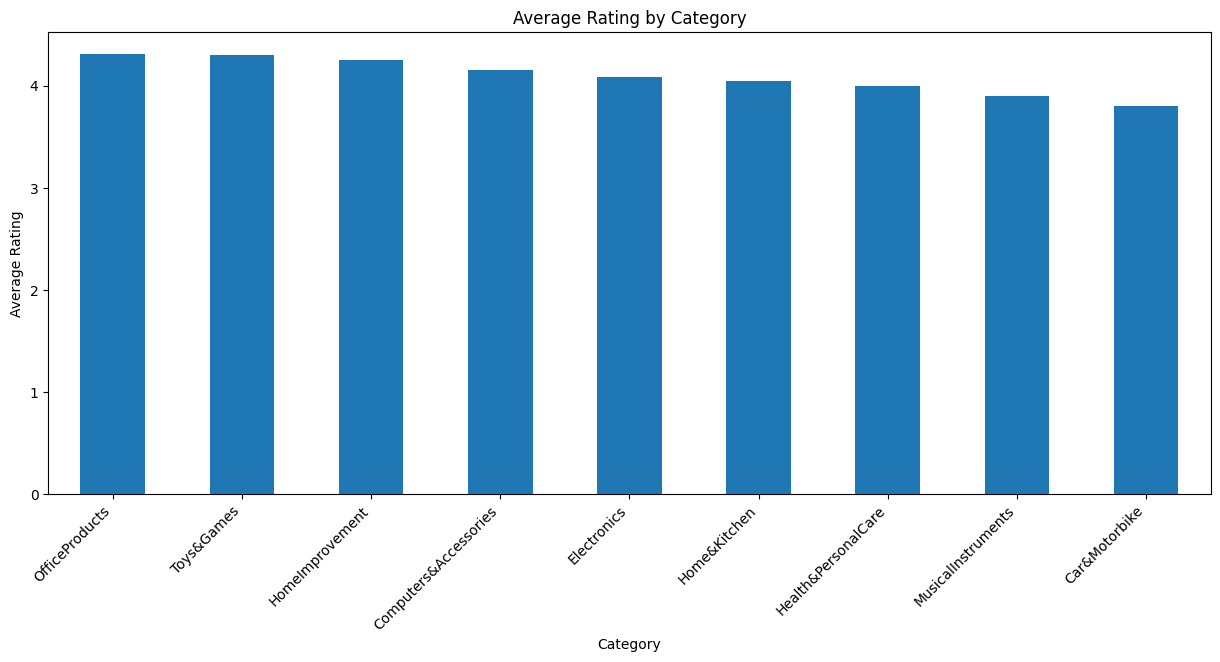

In [29]:
plt.figure(figsize=(15, 6))

category_rating.plot(kind='bar')

plt.title('Average Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')

plt.xticks(rotation=45, ha='right')

plt.show()

In [30]:
category_discount = (
    df_clean
    .groupby('main_category')['discount_percentage']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

display(category_discount)

,discount_percentage
main_category,
HomeImprovement,57.500000
Computers&Accessories,54.024283
Health&PersonalCare,53.000000
Electronics,50.828897
MusicalInstruments,46.000000
Car&Motorbike,42.000000
Home&Kitchen,40.120536
OfficeProducts,12.354839
Toys&Games,0.000000


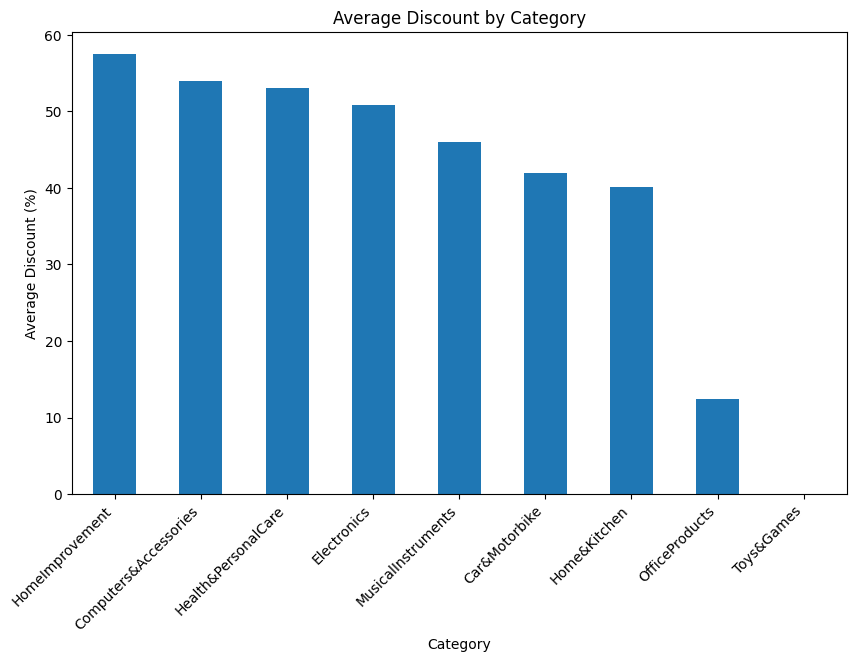

In [31]:
plt.figure(figsize=(10, 6))

category_discount.plot(kind='bar')

plt.title('Average Discount by Category')
plt.xlabel('Category')
plt.ylabel('Average Discount (%)')

plt.xticks(rotation=45, ha='right')

plt.show()

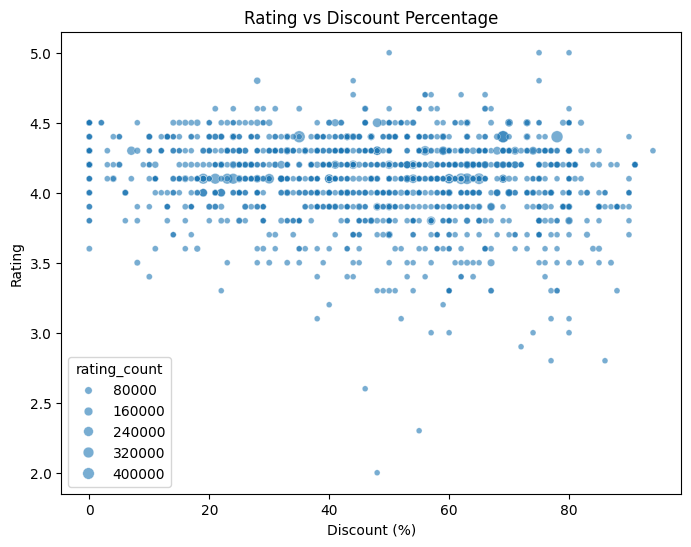

In [32]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clean,
    x='discount_percentage',
    y='rating',
    size='rating_count',
    alpha=0.6
)

plt.title('Rating vs Discount Percentage')
plt.xlabel('Discount (%)')
plt.ylabel('Rating')

plt.show()

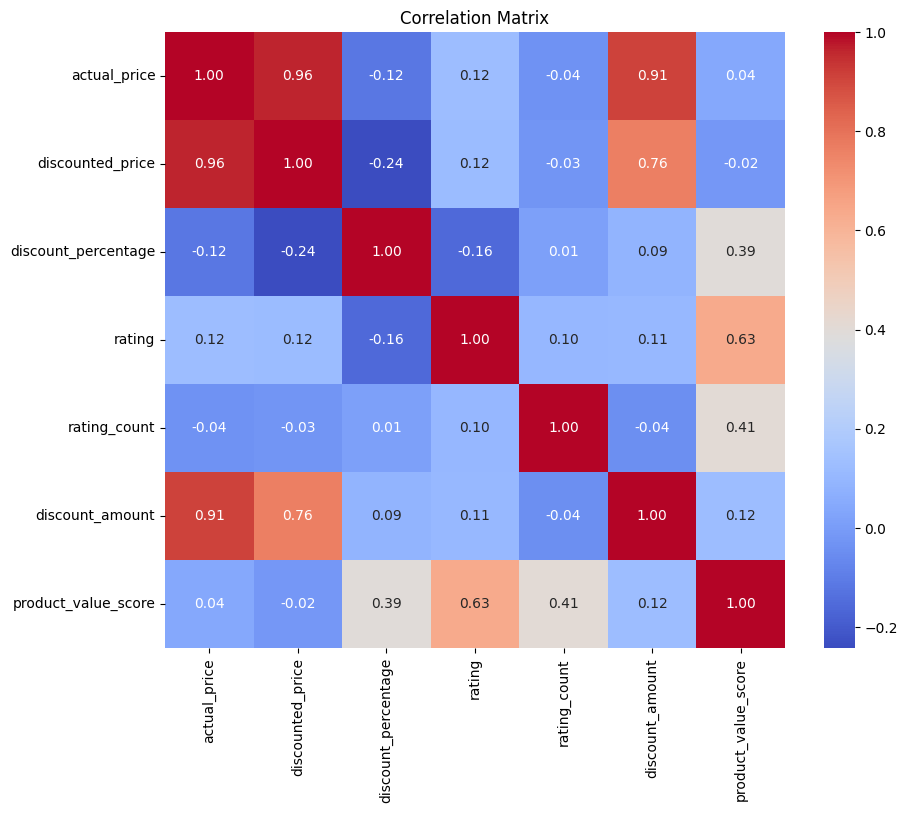

In [33]:
correlation_columns = [
    'actual_price',
    'discounted_price',
    'discount_percentage',
    'rating',
    'rating_count',
    'discount_amount',
    'product_value_score'
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    df_clean[correlation_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

# **AI MODEL**

In [34]:
features = [
    'actual_price',
    'discounted_price',
    'discount_percentage',
    'rating',
    'rating_count'
]

target = 'product_value_score'

X = df_clean[features]
y = df_clean[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

Features:
['actual_price', 'discounted_price', 'discount_percentage', 'rating', 'rating_count']

Target:
product_value_score


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 1172
Testing rows: 293


In [36]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [37]:
y_pred = model.predict(X_test)

print("Predictions generated.")

Predictions generated.


In [38]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-----------------")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

Model Performance
-----------------
MAE : 0.0068
RMSE: 0.0108
R²  : 0.9834


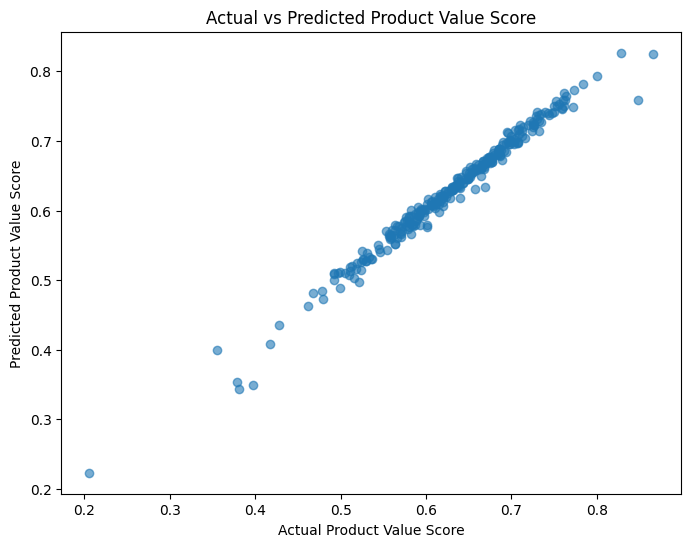

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel('Actual Product Value Score')
plt.ylabel('Predicted Product Value Score')

plt.title('Actual vs Predicted Product Value Score')

plt.show()

In [40]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

display(importance)

,Feature,Importance
4,rating_count,0.414821
3,rating,0.326381
2,discount_percentage,0.246994
1,discounted_price,0.006084
0,actual_price,0.005719


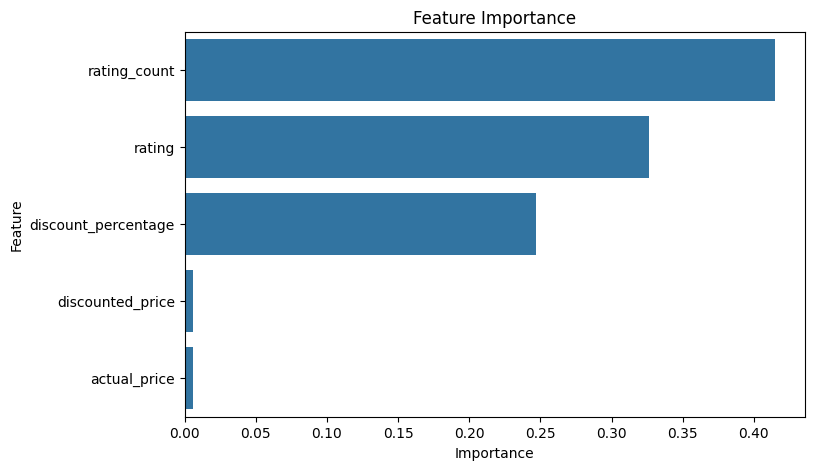

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')

plt.show()

# **PRODUCT RECOMMENDATION SYSTEM**

In [42]:
top_products = (
    df_clean
    .sort_values(
        'product_value_score',
        ascending=False
    )
    [
        [
            'product_name',
            'main_category',
            'actual_price',
            'discounted_price',
            'discount_percentage',
            'rating',
            'rating_count',
            'product_value_score'
        ]
    ]
    .head(20)
)

display(top_products)

,product_name,main_category,actual_price,discounted_price,discount_percentage,rating,rating_count,product_value_score
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pack),Black",Electronics,1400.0,309.0,78.0,4.4,426973.0,0.865957
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple MFi Certified] Lightning to Type C Fast Charging ...",Computers&Accessories,999.0,249.0,75.0,5.0,5179.0,0.848030
12,"AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot",Electronics,700.0,219.0,69.0,4.4,426973.0,0.846809
684,"AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot",Electronics,700.0,219.0,69.0,4.4,426972.0,0.846808
40,"AmazonBasics USB 2.0 Cable - A-Male to B-Male - for Personal Computer, Printer- 6 Feet (1.8 Mete...",Computers&Accessories,695.0,209.0,70.0,4.5,107687.0,0.830776
852,"AmazonBasics USB 2.0 Cable - A-Male to B-Male - for Personal Computer, Printer- 6 Feet (1.8 Mete...",Computers&Accessories,695.0,209.0,70.0,4.5,107686.0,0.830776
30,"AmazonBasics USB 2.0 - A-Male to A-Female Extension Cable for Personal Computer, Printer (Black,...",Computers&Accessories,750.0,199.0,73.0,4.5,74976.0,0.828006
802,"AmazonBasics USB 2.0 - A-Male to A-Female Extension Cable for Personal Computer, Printer (Black,...",Computers&Accessories,750.0,199.0,73.0,4.5,74976.0,0.828006
476,"ELV Aluminum Adjustable Mobile Phone Foldable Tabletop Stand Dock Mount for All Smartphones, Tab...",Electronics,1499.0,269.0,82.0,4.5,28978.0,0.823121
580,Elv Aluminium Adjustable Mobile Phone Foldable Holder Tabletop Stand Dock Mount for All Smartpho...,Electronics,1499.0,314.0,79.0,4.5,28978.0,0.816738


In [43]:
def recommend_products(
    category=None,
    max_price=None,
    min_rating=0,
    top_n=10
):

    results = df_clean.copy()

    # Filter category
    if category is not None:
        results = results[
            results['main_category'].str.contains(
                category,
                case=False,
                na=False
            )
        ]

    # Filter price
    if max_price is not None:
        results = results[
            results['discounted_price'] <= max_price
        ]

    # Filter rating
    results = results[
        results['rating'] >= min_rating
    ]

    # Sort by value score
    results = results.sort_values(
        'product_value_score',
        ascending=False
    )

    return results[
        [
            'product_name',
            'main_category',
            'discounted_price',
            'discount_percentage',
            'rating',
            'rating_count',
            'product_value_score'
        ]
    ].head(top_n)

In [44]:
recommend_products(
    max_price=2000,
    min_rating=4,
    top_n=10
)

,product_name,main_category,discounted_price,discount_percentage,rating,rating_count,product_value_score
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pack),Black",Electronics,309.0,78.0,4.4,426973.0,0.865957
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple MFi Certified] Lightning to Type C Fast Charging ...",Computers&Accessories,249.0,75.0,5.0,5179.0,0.848030
12,"AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot",Electronics,219.0,69.0,4.4,426973.0,0.846809
684,"AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot",Electronics,219.0,69.0,4.4,426972.0,0.846808
40,"AmazonBasics USB 2.0 Cable - A-Male to B-Male - for Personal Computer, Printer- 6 Feet (1.8 Mete...",Computers&Accessories,209.0,70.0,4.5,107687.0,0.830776
852,"AmazonBasics USB 2.0 Cable - A-Male to B-Male - for Personal Computer, Printer- 6 Feet (1.8 Mete...",Computers&Accessories,209.0,70.0,4.5,107686.0,0.830776
30,"AmazonBasics USB 2.0 - A-Male to A-Female Extension Cable for Personal Computer, Printer (Black,...",Computers&Accessories,199.0,73.0,4.5,74976.0,0.828006
802,"AmazonBasics USB 2.0 - A-Male to A-Female Extension Cable for Personal Computer, Printer (Black,...",Computers&Accessories,199.0,73.0,4.5,74976.0,0.828006
476,"ELV Aluminum Adjustable Mobile Phone Foldable Tabletop Stand Dock Mount for All Smartphones, Tab...",Electronics,269.0,82.0,4.5,28978.0,0.823121
580,Elv Aluminium Adjustable Mobile Phone Foldable Holder Tabletop Stand Dock Mount for All Smartpho...,Electronics,314.0,79.0,4.5,28978.0,0.816738


In [45]:
def search_products(keyword, top_n=10):

    results = df_clean[
        df_clean['product_name']
        .str.contains(
            keyword,
            case=False,
            na=False
        )
    ]

    results = results.sort_values(
        'product_value_score',
        ascending=False
    )

    return results[
        [
            'product_name',
            'main_category',
            'discounted_price',
            'discount_percentage',
            'rating',
            'rating_count',
            'product_value_score'
        ]
    ].head(top_n)

In [46]:
search_products('wireless')

,product_name,main_category,discounted_price,discount_percentage,rating,rating_count,product_value_score
56,TP-LINK WiFi Dongle 300 Mbps Mini Wireless Network USB Wi-Fi Adapter for PC Desktop Laptop(Suppo...,Computers&Accessories,649.0,54.0,4.2,179691.0,0.759679
8,"TP-Link USB WiFi Adapter for PC(TL-WN725N), N150 Wireless Network Adapter for Desktop - Nano Siz...",Computers&Accessories,499.0,50.0,4.2,179691.0,0.751168
883,"Infinity (JBL Glide 510, 72 Hrs Playtime with Quick Charge, Wireless On Ear Headphone with Mic, ...",Electronics,1499.0,63.0,4.2,42775.0,0.742540
143,TP-Link Nano USB WiFi Dongle 150Mbps High Gain Wireless Network Wi-Fi Adapter for PC Desktop and...,Computers&Accessories,749.0,44.0,4.2,179692.0,0.738402
656,Boult Audio Probass Curve Bluetooth Wireless in Ear Earphones with Mic with Ipx5 Water Resistant...,Electronics,899.0,80.0,3.8,103052.0,0.734274
720,"boAt Airdopes 171 in Ear Bluetooth True Wireless Earbuds with Upto 13 Hours Battery, IPX4, Bluet...",Electronics,1199.0,80.0,3.9,47521.0,0.731371
585,"boAt Airdopes 141 Bluetooth Truly Wireless in Ear Earbuds with mic, 42H Playtime, Beast Mode(Low...",Electronics,1499.0,67.0,3.9,136954.0,0.730472
701,"TP-Link TL-WA850RE Single_Band 300Mbps RJ45 Wireless Range Extender, Broadband/Wi-Fi Extender, W...",Computers&Accessories,1469.0,41.0,4.2,156638.0,0.728548
734,"Logitech M235 Wireless Mouse, 1000 DPI Optical Tracking, 12 Month Life Battery, Compatible with ...",Computers&Accessories,699.0,30.0,4.5,54405.0,0.728408
349,"PTron Tangentbeat in-Ear Bluetooth 5.0 Wireless Headphones with Mic, Enhanced Bass, 10mm Drivers...",Electronics,599.0,76.0,3.9,58162.0,0.727969


///


In [47]:
def get_dataset_summary():

    return {
        "total_products": len(df_clean),
        "categories": df_clean['main_category'].nunique(),
        "average_rating": round(df_clean['rating'].mean(), 2),
        "average_discount": round(
            df_clean['discount_percentage'].mean(), 2
        ),
        "average_price": round(
            df_clean['discounted_price'].mean(), 2
        )
    }

In [48]:
get_dataset_summary()

{'total_products': 1465,
 'categories': 9,
 'average_rating': np.float64(4.1),
 'average_discount': np.float64(47.69),
 'average_price': np.float64(3125.31)}

In [49]:
def best_category():

    result = (
        df_clean
        .groupby('main_category')
        .agg(
            average_rating=('rating', 'mean'),
            average_discount=('discount_percentage', 'mean'),
            product_count=('product_id', 'count')
        )
        .sort_values(
            'average_rating',
            ascending=False
        )
    )

    return result.head(10)

In [50]:
best_category()

,average_rating,average_discount,product_count
main_category,,,
OfficeProducts,4.309677,12.354839,31
Toys&Games,4.300000,0.000000,1
HomeImprovement,4.250000,57.500000,2
Computers&Accessories,4.154967,54.024283,453
Electronics,4.081749,50.828897,526
Home&Kitchen,4.040848,40.120536,448
Health&PersonalCare,4.000000,53.000000,1
MusicalInstruments,3.900000,46.000000,2
Car&Motorbike,3.800000,42.000000,1


In [51]:
def best_value_products(top_n=10):

    return (
        df_clean
        .sort_values(
            'product_value_score',
            ascending=False
        )
        [
            [
                'product_name',
                'main_category',
                'discounted_price',
                'discount_percentage',
                'rating',
                'rating_count',
                'product_value_score'
            ]
        ]
        .head(top_n)
    )

In [52]:
best_value_products()

,product_name,main_category,discounted_price,discount_percentage,rating,rating_count,product_value_score
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pack),Black",Electronics,309.0,78.0,4.4,426973.0,0.865957
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple MFi Certified] Lightning to Type C Fast Charging ...",Computers&Accessories,249.0,75.0,5.0,5179.0,0.848030
12,"AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot",Electronics,219.0,69.0,4.4,426973.0,0.846809
684,"AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot",Electronics,219.0,69.0,4.4,426972.0,0.846808
40,"AmazonBasics USB 2.0 Cable - A-Male to B-Male - for Personal Computer, Printer- 6 Feet (1.8 Mete...",Computers&Accessories,209.0,70.0,4.5,107687.0,0.830776
852,"AmazonBasics USB 2.0 Cable - A-Male to B-Male - for Personal Computer, Printer- 6 Feet (1.8 Mete...",Computers&Accessories,209.0,70.0,4.5,107686.0,0.830776
30,"AmazonBasics USB 2.0 - A-Male to A-Female Extension Cable for Personal Computer, Printer (Black,...",Computers&Accessories,199.0,73.0,4.5,74976.0,0.828006
802,"AmazonBasics USB 2.0 - A-Male to A-Female Extension Cable for Personal Computer, Printer (Black,...",Computers&Accessories,199.0,73.0,4.5,74976.0,0.828006
476,"ELV Aluminum Adjustable Mobile Phone Foldable Tabletop Stand Dock Mount for All Smartphones, Tab...",Electronics,269.0,82.0,4.5,28978.0,0.823121
580,Elv Aluminium Adjustable Mobile Phone Foldable Holder Tabletop Stand Dock Mount for All Smartpho...,Electronics,314.0,79.0,4.5,28978.0,0.816738


In [53]:
def product_analyst(question):

    question = question.lower()

    # Best products
    if (
        'best product' in question
        or 'best products' in question
        or 'best value' in question
    ):
        result = best_value_products(5)

        return result

    # Category
    elif (
        'category' in question
        and (
            'best' in question
            or 'highest' in question
        )
    ):
        return best_category()

    # Average rating
    elif 'average rating' in question:

        return round(
            df_clean['rating'].mean(),
            2
        )

    # Discount
    elif 'discount' in question:

        return round(
            df_clean['discount_percentage'].mean(),
            2
        )

    # Number of products
    elif (
        'how many products' in question
        or 'number of products' in question
    ):

        return len(df_clean)

    else:

        return (
            "I can answer questions about products, "
            "ratings, discounts, prices and categories."
        )

In [54]:
joblib.dump(
    model,
    'product_value_model.pkl'
)

print("product_value_model.pkl saved!")

product_value_model.pkl saved!


In [57]:
import os

print(os.listdir('.'))

['.config', 'product_value_model.pkl', 'sample_data']


In [58]:
# Save the cleaned dataset as a CSV

df_clean.to_csv(
    'amazon_clean.csv',
    index=False
)

print("amazon_clean.csv created successfully!")
print("Shape:", df_clean.shape)

amazon_clean.csv created successfully!
Shape: (1465, 24)


In [59]:
import os

print(os.listdir())


['.config', 'product_value_model.pkl', 'amazon_clean.csv', 'sample_data']


In [60]:
from google.colab import files

files.download('amazon_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **K-Means + TF-IDF**

In [61]:
# ============================================================
# AMAZON PRODUCT INTELLIGENCE
# AI RECOMMENDATION SYSTEM
# K-MEANS + TF-IDF + COSINE SIMILARITY
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# 1. CHECK DATA
# ============================================================

print("=" * 60)
print("AMAZON PRODUCT INTELLIGENCE - AI PIPELINE")
print("=" * 60)

print("\nDataset shape:", df_clean.shape)
print("Columns:", list(df_clean.columns))


# ============================================================
# 2. PREPARE DATA
# ============================================================

df_ai = df_clean.copy()

# Make sure important numeric columns are numeric
numeric_columns = [
    "actual_price",
    "discounted_price",
    "discount_percentage",
    "rating",
    "rating_count"
]

for col in numeric_columns:
    df_ai[col] = pd.to_numeric(df_ai[col], errors="coerce")

# Fill missing values
for col in numeric_columns:
    df_ai[col] = df_ai[col].fillna(df_ai[col].median())

# Make sure text columns exist
text_columns = [
    "product_name",
    "category",
    "about_product"
]

for col in text_columns:
    if col not in df_ai.columns:
        df_ai[col] = ""

    df_ai[col] = df_ai[col].fillna("").astype(str)


# ============================================================
# 3. CREATE LOG REVIEW COUNT
# ============================================================

df_ai["log_rating_count"] = np.log1p(df_ai["rating_count"])


# ============================================================
# 4. K-MEANS PRODUCT CLUSTERING
# ============================================================

print("\n" + "=" * 60)
print("STEP 1: PRODUCT CLUSTERING")
print("=" * 60)

cluster_features = [
    "actual_price",
    "discounted_price",
    "discount_percentage",
    "rating",
    "log_rating_count"
]

X_cluster = df_ai[cluster_features].copy()

# Scale features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)


# ============================================================
# 5. FIND BEST NUMBER OF CLUSTERS
# ============================================================

print("\nTesting different cluster sizes...")

silhouette_scores = {}

for k in range(2, 9):

    kmeans_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans_test.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores[k] = score

    print(f"K = {k} | Silhouette Score = {score:.4f}")


# Find best K
best_k = max(
    silhouette_scores,
    key=silhouette_scores.get
)

print("\nBest number of clusters:", best_k)
print(
    "Best silhouette score:",
    round(silhouette_scores[best_k], 4)
)


# ============================================================
# 6. TRAIN FINAL K-MEANS MODEL
# ============================================================

kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df_ai["cluster"] = kmeans_model.fit_predict(X_scaled)


print("\nCluster distribution:")
print(df_ai["cluster"].value_counts().sort_index())


# ============================================================
# 7. CLUSTER SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("CLUSTER ANALYSIS")
print("=" * 60)

cluster_summary = (
    df_ai
    .groupby("cluster")
    .agg(
        products=("product_id", "count"),
        avg_price=("discounted_price", "mean"),
        avg_rating=("rating", "mean"),
        avg_discount=("discount_percentage", "mean"),
        avg_reviews=("rating_count", "mean")
    )
    .round(2)
)

print(cluster_summary)


# ============================================================
# 8. AUTOMATIC CLUSTER LABELS
# ============================================================

def describe_cluster(row):

    price = row["avg_price"]
    rating = row["avg_rating"]
    discount = row["avg_discount"]

    if rating >= 4.2 and discount >= 40:
        return "Highly Rated & High Discount"

    elif rating >= 4.2 and price < df_ai["discounted_price"].median():
        return "Highly Rated Budget Products"

    elif price > df_ai["discounted_price"].median():
        return "Premium Products"

    elif discount >= 50:
        return "High Discount Products"

    else:
        return "Standard Products"


cluster_summary["cluster_type"] = cluster_summary.apply(
    describe_cluster,
    axis=1
)

print("\nCluster types:")
print(
    cluster_summary[
        ["products", "avg_price", "avg_rating",
         "avg_discount", "cluster_type"]
    ]
)


# ============================================================
# 9. TF-IDF TEXT PROCESSING
# ============================================================

print("\n" + "=" * 60)
print("STEP 2: NLP PRODUCT RECOMMENDATION")
print("=" * 60)


# Combine product information
df_ai["combined_text"] = (
    df_ai["product_name"].astype(str)
    + " "
    + df_ai["category"].astype(str)
    + " "
    + df_ai["about_product"].astype(str)
)


# Clean text
def clean_text(text):

    text = str(text).lower()

    # Remove HTML
    text = re.sub(r"<.*?>", " ", text)

    # Remove special characters
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()


df_ai["combined_text"] = df_ai["combined_text"].apply(clean_text)


# ============================================================
# 10. CREATE TF-IDF VECTORS
# ============================================================

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    df_ai["combined_text"]
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)


# ============================================================
# 11. COSINE SIMILARITY
# ============================================================

print("\nCalculating product similarity...")

cosine_sim = cosine_similarity(tfidf_matrix)

print("Similarity matrix shape:", cosine_sim.shape)


# ============================================================
# 12. PRODUCT INDEX
# ============================================================

# Product names can sometimes repeat.
# Product ID is therefore preferred as the unique identifier.

product_indices = pd.Series(
    df_ai.index,
    index=df_ai["product_id"]
)

product_name_indices = pd.Series(
    df_ai.index,
    index=df_ai["product_name"]
)


# ============================================================
# 13. RECOMMENDATION FUNCTION
# ============================================================

def recommend_products(
    product_name,
    number_of_recommendations=5
):

    # Find matching product
    matches = df_ai[
        df_ai["product_name"]
        .str.contains(
            str(product_name),
            case=False,
            na=False
        )
    ]

    if len(matches) == 0:

        print(
            f"No product found matching: {product_name}"
        )

        return pd.DataFrame()

    # Use first matching product
    product_index = matches.index[0]

    # Get similarity scores
    similarity_scores = list(
        enumerate(cosine_sim[product_index])
    )

    # Sort from most similar to least similar
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the original product
    similarity_scores = [
        item
        for item in similarity_scores
        if item[0] != product_index
    ]

    # Select recommendations
    top_products = similarity_scores[
        :number_of_recommendations
    ]

    recommendation_indices = [
        item[0]
        for item in top_products
    ]

    recommendation_scores = [
        item[1]
        for item in top_products
    ]

    recommendations = df_ai.loc[
        recommendation_indices,
        [
            "product_id",
            "product_name",
            "category",
            "discounted_price",
            "actual_price",
            "rating",
            "rating_count",
            "discount_percentage",
            "cluster"
        ]
    ].copy()

    recommendations["similarity_score"] = [
        round(score, 4)
        for score in recommendation_scores
    ]

    recommendations = recommendations.reset_index(
        drop=True
    )

    return recommendations


# ============================================================
# 14. TEST RECOMMENDATION SYSTEM
# ============================================================

print("\n" + "=" * 60)
print("TESTING RECOMMENDATION SYSTEM")
print("=" * 60)

test_product = df_ai.iloc[0]["product_name"]

print("\nSelected product:")
print(test_product)

print("\nRecommended products:")

test_recommendations = recommend_products(
    test_product,
    number_of_recommendations=5
)

display(test_recommendations)


# ============================================================
# 15. RECOMMENDATIONS BY CATEGORY
# ============================================================

def recommend_by_category(
    category,
    number_of_recommendations=10
):

    filtered = df_ai[
        df_ai["main_category"]
        .astype(str)
        .str.contains(
            str(category),
            case=False,
            na=False
        )
    ].copy()

    if filtered.empty:

        print(
            f"No products found in category: {category}"
        )

        return pd.DataFrame()

    # Sort using existing value score if available
    if "product_value_score" in filtered.columns:

        filtered = filtered.sort_values(
            "product_value_score",
            ascending=False
        )

    else:

        filtered = filtered.sort_values(
            ["rating", "rating_count"],
            ascending=[False, False]
        )

    return filtered[
        [
            "product_id",
            "product_name",
            "category",
            "discounted_price",
            "rating",
            "rating_count",
            "discount_percentage",
            "cluster"
        ]
    ].head(number_of_recommendations)


# ============================================================
# 16. SEARCH PRODUCTS
# ============================================================

def search_products(
    keyword,
    top_n=10
):

    keyword = str(keyword).strip()

    results = df_ai[
        df_ai["product_name"]
        .str.contains(
            keyword,
            case=False,
            na=False
        )
    ].copy()

    if results.empty:

        print(
            f"No products found for: {keyword}"
        )

        return pd.DataFrame()

    if "product_value_score" in results.columns:

        results = results.sort_values(
            "product_value_score",
            ascending=False
        )

    else:

        results = results.sort_values(
            ["rating", "rating_count"],
            ascending=[False, False]
        )

    return results[
        [
            "product_id",
            "product_name",
            "category",
            "discounted_price",
            "actual_price",
            "rating",
            "rating_count",
            "discount_percentage",
            "cluster"
        ]
    ].head(top_n)


# ============================================================
# 17. CATEGORY SEARCH
# ============================================================

def search_category(
    keyword,
    top_n=20
):

    keyword = str(keyword).strip()

    results = df_ai[
        df_ai["category"]
        .str.contains(
            keyword,
            case=False,
            na=False
        )
    ].copy()

    if results.empty:

        print(
            f"No products found for category: {keyword}"
        )

        return pd.DataFrame()

    return results[
        [
            "product_id",
            "product_name",
            "category",
            "discounted_price",
            "rating",
            "rating_count",
            "discount_percentage",
            "cluster"
        ]
    ].head(top_n)


# ============================================================
# 18. TOP VALUE PRODUCTS
# ============================================================

def get_top_products(top_n=10):

    if "product_value_score" in df_ai.columns:

        results = df_ai.sort_values(
            "product_value_score",
            ascending=False
        )

    else:

        results = df_ai.sort_values(
            ["rating", "rating_count"],
            ascending=[False, False]
        )

    return results[
        [
            "product_id",
            "product_name",
            "category",
            "discounted_price",
            "rating",
            "rating_count",
            "discount_percentage",
            "cluster"
        ]
    ].head(top_n)


# ============================================================
# 19. DATASET SUMMARY
# ============================================================

def get_dataset_summary():

    return {
        "total_products": len(df_ai),
        "categories": df_ai["main_category"].nunique(),
        "average_rating": round(
            df_ai["rating"].mean(),
            2
        ),
        "average_discount": round(
            df_ai["discount_percentage"].mean(),
            2
        ),
        "average_price": round(
            df_ai["discounted_price"].mean(),
            2
        ),
        "clusters": best_k
    }


print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print(get_dataset_summary())


# ============================================================
# 20. CREATE MODEL DIRECTORY
# ============================================================

os.makedirs("models", exist_ok=True)


# ============================================================
# 21. SAVE K-MEANS MODEL
# ============================================================

joblib.dump(
    kmeans_model,
    "models/kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)


# ============================================================
# 22. SAVE TF-IDF MODEL
# ============================================================

joblib.dump(
    tfidf_vectorizer,
    "models/tfidf_vectorizer.pkl"
)


# ============================================================
# 23. SAVE COSINE SIMILARITY MATRIX
# ============================================================

joblib.dump(
    cosine_sim,
    "models/cosine_similarity.pkl"
)


# ============================================================
# 24. SAVE RECOMMENDATION DATA
# ============================================================

recommendation_data = df_ai[
    [
        "product_id",
        "product_name",
        "category",
        "main_category",
        "discounted_price",
        "actual_price",
        "discount_percentage",
        "rating",
        "rating_count",
        "cluster"
    ]
].copy()

joblib.dump(
    recommendation_data,
    "models/recommendation_data.pkl"
)


# ============================================================
# 25. SAVE CLUSTER SUMMARY
# ============================================================

cluster_summary.to_csv(
    "models/cluster_summary.csv"
)


# ============================================================
# 26. SAVE AI DATASET
# ============================================================

df_ai.to_csv(
    "amazon_ai_dataset.csv",
    index=False
)


# ============================================================
# 27. SAVE SIMILARITY DATA
# ============================================================

print("\n" + "=" * 60)
print("SAVED FILES")
print("=" * 60)

for root, dirs, files in os.walk("."):

    for file in files:

        if (
            file.endswith(".pkl")
            or file.endswith(".csv")
        ):

            print(
                os.path.join(root, file)
            )


# ============================================================
# 28. FINAL TESTS
# ============================================================

print("\n" + "=" * 60)
print("FINAL AI SYSTEM TEST")
print("=" * 60)

print("\n1. Search test:")
display(
    search_products(
        "headphone",
        top_n=5
    )
)

print("\n2. Category test:")
display(
    search_category(
        "cables",
        top_n=5
    )
)

print("\n3. Top products test:")
display(
    get_top_products(
        top_n=5
    )
)

print("\n4. Recommendation test:")
display(
    recommend_products(
        test_product,
        number_of_recommendations=5
    )
)


# ============================================================
# 29. COMPLETE
# ============================================================

print("\n" + "=" * 60)
print("AI PIPELINE COMPLETED SUCCESSFULLY!")
print("=" * 60)

print(f"""
Products processed       : {len(df_ai)}
Product clusters          : {best_k}
TF-IDF features           : {tfidf_matrix.shape[1]}
Similarity matrix         : {cosine_sim.shape}

Saved AI models:
✓ K-Means model
✓ StandardScaler
✓ TF-IDF vectorizer
✓ Cosine similarity matrix
✓ Recommendation dataset
✓ Cluster summary

Next step:
Connect these AI models to the Azure + Streamlit application.
""")

AMAZON PRODUCT INTELLIGENCE - AI PIPELINE

Dataset shape: (1465, 24)
Columns: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link', 'discount_amount', 'price_ratio', 'review_popularity', 'rating_score', 'review_score', 'discount_score', 'product_value_score', 'main_category']

STEP 1: PRODUCT CLUSTERING

Testing different cluster sizes...
K = 2 | Silhouette Score = 0.5101
K = 3 | Silhouette Score = 0.2448
K = 4 | Silhouette Score = 0.2493
K = 5 | Silhouette Score = 0.2490
K = 6 | Silhouette Score = 0.2689
K = 7 | Silhouette Score = 0.2571
K = 8 | Silhouette Score = 0.2343

Best number of clusters: 2
Best silhouette score: 0.5101

Cluster distribution:
cluster
0    1349
1     116
Name: count, dtype: int64

CLUSTER ANALYSIS
         products  avg_price  avg_rating  avg_discount  avg_reviews
cluster   

/tmp/ipykernel_2622/872825023.py:316: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(


""



DATASET SUMMARY
{'total_products': 1465, 'categories': 9, 'average_rating': np.float64(4.1), 'average_discount': np.float64(47.69), 'average_price': np.float64(3125.31), 'clusters': 2}

SAVED FILES
./product_value_model.pkl
./amazon_clean.csv
./amazon_ai_dataset.csv
./models/cluster_summary.csv
./models/kmeans_model.pkl
./models/recommendation_data.pkl
./models/tfidf_vectorizer.pkl
./models/cosine_similarity.pkl
./models/scaler.pkl
./sample_data/mnist_test.csv
./sample_data/mnist_train_small.csv
./sample_data/california_housing_train.csv
./sample_data/california_housing_test.csv

FINAL AI SYSTEM TEST

1. Search test:


,product_id,product_name,category,discounted_price,actual_price,rating,rating_count,discount_percentage,cluster
584,B071Z8M4KX,boAt BassHeads 100 in-Ear Wired Headphones with Mic (Black),"Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear",365.0,999.0,4.1,363711.0,63.0,0
1015,B078W65FJ7,boAt BassHeads 900 On-Ear Wired Headphones with Mic (White),"Electronics|Headphones,Earbuds&Accessories|Headphones|On-Ear",849.0,2490.0,4.2,91188.0,66.0,0
599,B07PR1CL3S,"boAt Rockerz 450 Bluetooth On Ear Headphones with Mic, Upto 15 Hours Playback, 40MM Drivers, Pad...","Electronics|Headphones,Earbuds&Accessories|Headphones|On-Ear",1220.0,3990.0,4.1,107151.0,69.0,0
479,B01DF26V7A,"JBL C100SI Wired In Ear Headphones with Mic, JBL Pure Bass Sound, One Button Multi-function Remo...","Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear",599.0,1299.0,4.1,192589.0,54.0,0
883,B0873L7J6X,"Infinity (JBL Glide 510, 72 Hrs Playtime with Quick Charge, Wireless On Ear Headphone with Mic, ...","Electronics|Headphones,Earbuds&Accessories|Headphones|On-Ear",1499.0,3999.0,4.2,42775.0,63.0,0


...

,product_id,product_name,category,discounted_price,rating,rating_count,discount_percentage,cluster
65,B014I8SX4Y,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pack),Black","Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables",309.0,4.4,426973.0,78.0,0
324,B0BQRJ3C47,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple MFi Certified] Lightning to Type C Fast Charging ...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,249.0,5.0,5179.0,75.0,0
12,B07KSMBL2H,"AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot","Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables",219.0,4.4,426973.0,69.0,0
684,B07KSMBL2H,"AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot","Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables",219.0,4.4,426972.0,69.0,0
40,B00NH11KIK,"AmazonBasics USB 2.0 Cable - A-Male to B-Male - for Personal Computer, Printer- 6 Feet (1.8 Mete...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,209.0,4.5,107687.0,70.0,0



4. Recommendation test:
No product found matching: Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13, 12,11, X, 8, 7, 6, 5, iPad Air, Pro, Mini (3 FT Pack of 1, Grey)


/tmp/ipykernel_2622/872825023.py:316: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(


""



AI PIPELINE COMPLETED SUCCESSFULLY!

Products processed       : 1465
Product clusters          : 2
TF-IDF features           : 5000
Similarity matrix         : (1465, 1465)

Saved AI models:
✓ K-Means model
✓ StandardScaler
✓ TF-IDF vectorizer
✓ Cosine similarity matrix
✓ Recommendation dataset
✓ Cluster summary

Next step:
Connect these AI models to the Azure + Streamlit application.



In [62]:
from google.colab import files
import shutil
import os

# Create a zip containing all AI model files
shutil.make_archive(
    "amazon_ai_models",
    "zip",
    "models"
)

print("Created: amazon_ai_models.zip")

files.download("amazon_ai_models.zip")

Created: amazon_ai_models.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>